In [32]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from scipy.spatial import cKDTree
from pathlib import Path
import matplotlib.pyplot as plt
import gc

SIM_DIR    = Path("/nvme1/users/md962/glacier/Glacier Project/Sim_Merged/")
MODELS_DIR = Path("/nvme1/users/md962/glacier/Glacier Project/Final_Models/")
RESULTS_DIR = Path("/nvme1/users/md962/glacier/Glacier Project/Results/")
PARQUET_DIR = Path("/nvme1/users/md962/glacier/Glacier Project/Merged/")


AE_COLS              = [f'A{i:02d}' for i in range(64)]
DEVICE               = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
PIXEL_AREA           = (10 * 10) / 1e6   # km²
ANNUAL_MELT_FRACTION = 0.0155            # 1.55% per year, observed 2017-2025
PRIMARY_ALPHA        = 0.4
SENSITIVITY_ALPHAS   = [0.2, 0.4, 0.6]
N_STEPS              = 30                # 2025 → 2055

print(f"Device:               {DEVICE}")
print(f"Annual melt fraction: {ANNUAL_MELT_FRACTION*100:.2f}%")
print(f"Primary alpha:        {PRIMARY_ALPHA}")
print(f"Steps:                {N_STEPS} (2025→2055)")

Device:               cuda
Annual melt fraction: 1.55%
Primary alpha:        0.4
Steps:                30 (2025→2055)


In [28]:
print("Loading 2025 simulation parquets...")
dfs = []
for region in ['r3', 'r1a', 'r1b', 'r2']:
    df = pd.read_parquet(SIM_DIR / f'sim_2025_{region}.parquet')
    df['region'] = region
    dfs.append(df)

df_sim = pd.concat(dfs, ignore_index=True)
df_sim = df_sim.drop_duplicates(subset=['lon', 'lat'], keep='first').reset_index(drop=True)
print(f"2025 starting pixels: {len(df_sim):,}")
print(f"Starting ice area:    {len(df_sim) * PIXEL_AREA:.2f} km²")

# Compute mean melt embedding from training data
print("\nComputing mean melt embedding...")
df_train = pd.read_parquet(
    Path("/nvme1/users/md962/glacier/Glacier Project/Predictions/predictions_full_peru_r3holdout.parquet")
)
# Load full training parquets to get melt labels and embeddings
dfs_train = []
for region in ['r3', 'r1a', 'r1b', 'r2']:
    df = pd.read_parquet(Path("/nvme1/users/md962/glacier/Glacier Project/Merged/") / f'{region}_combined.parquet')
    dfs_train.append(df)
df_2017 = pd.concat(dfs_train, ignore_index=True)
df_2017 = df_2017.drop_duplicates(subset=['lon', 'lat'], keep='first').reset_index(drop=True)

mean_melt_emb = df_2017[df_2017['melt_label'] == 1][AE_COLS].values.mean(axis=0).astype(np.float32)
print(f"Mean melt embedding from {(df_2017['melt_label']==1).sum():,} melt pixels")

# Pixel spacing
pixel_lon = np.median(np.diff(np.sort(df_sim['lon'].unique())))
pixel_lat = np.median(np.diff(np.sort(df_sim['lat'].unique())))
print(f"Pixel spacing: lon={pixel_lon:.8f}, lat={pixel_lat:.8f}")

del df_2017, dfs_train
gc.collect()

Loading 2025 simulation parquets...
2025 starting pixels: 12,260,700
Starting ice area:    1226.07 km²

Computing mean melt embedding...
Mean melt embedding from 2,751,035 melt pixels
Pixel spacing: lon=0.00008983, lat=0.00008983


27

In [33]:
class GlacierMLP(nn.Module):
    def __init__(self, dropout=0.5):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(64, 512), nn.BatchNorm1d(512), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(512, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(256, 128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(128, 1)
        )
    def forward(self, x):
        return self.net(x).squeeze(1)

mlp_model = GlacierMLP(dropout=0.5).to(DEVICE)
mlp_model.load_state_dict(torch.load(
    MODELS_DIR / 'MLP_AE64_R3HOLDOUT.pt', weights_only=True))
mlp_model.eval()
print("MLP loaded ✓")

def predict_mlp(embeddings_np, batch_size=65536):
    embeddings = torch.from_numpy(embeddings_np).to(DEVICE)
    probs = []
    with torch.no_grad():
        for start in range(0, len(embeddings), batch_size):
            logits = mlp_model(embeddings[start:start+batch_size])
            probs.extend(torch.sigmoid(logits).cpu().numpy())
    del embeddings
    torch.cuda.empty_cache()
    return np.array(probs, dtype=np.float32)

MLP loaded ✓


In [34]:
def run_simulation(df_start, alpha, n_steps=30, verbose=True):
    """
    Annual iterative glacier melt simulation.
    
    The MLP ranks pixels by melt susceptibility. At each timestep the top 
    ANNUAL_MELT_FRACTION of remaining pixels are designated as melted.
    Embeddings of surviving boundary pixels are nudged toward the mean melt 
    embedding proportional to how many of their neighbours melted (strength α).
    
    Parameters:
    - alpha:   embedding update strength (0=none, 1=full replacement)
    - n_steps: number of annual timesteps
    """
    embeddings   = df_start[AE_COLS].values.astype(np.float32).copy()
    lons         = df_start['lon'].values.astype(np.float64).copy()
    lats         = df_start['lat'].values.astype(np.float64).copy()
    orig_indices = np.arange(len(df_start))
    melt_years   = np.zeros(len(df_start), dtype=np.int32)
    start_year   = 2025
    n_start      = len(embeddings)
    area_history = [(start_year, n_start * PIXEL_AREA)]
    
    for step in range(n_steps):
        year      = start_year + step
        next_year = year + 1
        n_current = len(embeddings)
        
        if n_current == 0:
            break
        
        # Rank pixels by melt susceptibility, select top N
        n_melt    = max(1, int(n_current * ANNUAL_MELT_FRACTION))
        probs     = predict_mlp(embeddings)
        top_idx   = np.argsort(probs)[::-1][:n_melt]
        melt_mask = np.zeros(n_current, dtype=bool)
        melt_mask[top_idx] = True
        
        # Record melt year
        melt_years[orig_indices[melt_mask]] = next_year
        
        # Neighbourhood embedding update
        surviving_mask  = ~melt_mask
        surv_lons       = lons[surviving_mask]
        surv_lats       = lats[surviving_mask]
        surv_embeddings = embeddings[surviving_mask]
        
        if alpha > 0 and n_melt > 0:
            melted_coords    = np.stack([lons[melt_mask], lats[melt_mask]], axis=1)
            tree_melted      = cKDTree(melted_coords)
            surv_coords      = np.stack([surv_lons, surv_lats], axis=1)
            neighbour_radius = 1.5 * max(pixel_lon, pixel_lat)
            counts  = tree_melted.query_ball_point(
                surv_coords, r=neighbour_radius, return_length=True)
            counts  = np.minimum(counts, 8)
            alpha_i = (counts / 8.0) * alpha
            alpha_i = alpha_i[:, np.newaxis]
            surv_embeddings = ((1 - alpha_i) * surv_embeddings +
                               alpha_i * mean_melt_emb[np.newaxis, :])
        
        embeddings   = surv_embeddings.astype(np.float32)
        lons         = surv_lons
        lats         = surv_lats
        orig_indices = orig_indices[surviving_mask]
        
        ice_area = len(embeddings) * PIXEL_AREA
        area_history.append((next_year, ice_area))
        
        del probs
        gc.collect()
        
        if verbose and (step + 1) % 5 == 0:
            pct_lost = (1 - ice_area / (n_start * PIXEL_AREA)) * 100
            print(f"  Year {next_year}: {len(embeddings):,} pixels, "
                  f"{ice_area:.2f} km² ({pct_lost:.1f}% lost from 2025)")
    
    # Build output dataframe
    df_out = df_start[['lon', 'lat', 'region']].copy()
    df_out['melt_year'] = melt_years  # 0 = survived to end of simulation
    
    return area_history, df_out

In [35]:
start_area = len(df_sim) * PIXEL_AREA
print(f"Starting ice area (2025): {start_area:.2f} km²\n")

# Primary simulation
print(f"=== PRIMARY SIMULATION (α={PRIMARY_ALPHA}) ===")
primary_history, primary_df = run_simulation(df_sim, PRIMARY_ALPHA, N_STEPS)

# Sensitivity analysis
sensitivity_histories = {PRIMARY_ALPHA: primary_history}
for alpha in SENSITIVITY_ALPHAS:
    if alpha == PRIMARY_ALPHA:
        continue
    print(f"\n=== SENSITIVITY: α={alpha} ===")
    hist, _ = run_simulation(df_sim, alpha, N_STEPS, verbose=False)
    sensitivity_histories[alpha] = hist

print("\nAll simulations complete")

Starting ice area (2025): 1226.07 km²

=== PRIMARY SIMULATION (α=0.4) ===
  Year 2030: 11,339,501 pixels, 1133.95 km² (7.5% lost from 2025)
  Year 2035: 10,487,517 pixels, 1048.75 km² (14.5% lost from 2025)
  Year 2040: 9,699,546 pixels, 969.95 km² (20.9% lost from 2025)
  Year 2045: 8,970,779 pixels, 897.08 km² (26.8% lost from 2025)
  Year 2050: 8,296,766 pixels, 829.68 km² (32.3% lost from 2025)
  Year 2055: 7,673,395 pixels, 767.34 km² (37.4% lost from 2025)

=== SENSITIVITY: α=0.2 ===

=== SENSITIVITY: α=0.6 ===

All simulations complete


In [36]:
for alpha in sorted(SENSITIVITY_ALPHAS):
    hist = sensitivity_histories[alpha]
    area_2050 = dict(hist).get(2050)
    area_2055 = dict(hist).get(2055)
    loss_2050 = (start_area - area_2050) / start_area * 100
    loss_2055 = (start_area - area_2055) / start_area * 100
    print(f"α={alpha}: 2050={area_2050:.2f} km² ({loss_2050:.1f}% lost), "
          f"2055={area_2055:.2f} km² ({loss_2055:.1f}% lost)")

α=0.2: 2050=829.68 km² (32.3% lost), 2055=767.34 km² (37.4% lost)
α=0.4: 2050=829.68 km² (32.3% lost), 2055=767.34 km² (37.4% lost)
α=0.6: 2050=829.68 km² (32.3% lost), 2055=767.34 km² (37.4% lost)


In [37]:
print(f"\n=== PROJECTION RESULTS (α={PRIMARY_ALPHA}) ===\n")
print(f"{'Year':<6} {'Ice Area (km²)':>15} {'Loss (km²)':>12} {'Loss %':>8}")
print("-" * 45)

for year, area in primary_history:
    loss_km2 = start_area - area
    loss_pct = loss_km2 / start_area * 100
    print(f"{year:<6} {area:>15.2f} {loss_km2:>12.2f} {loss_pct:>7.1f}%")


=== PROJECTION RESULTS (α=0.4) ===

Year    Ice Area (km²)   Loss (km²)   Loss %
---------------------------------------------
2025           1226.07         0.00     0.0%
2026           1207.07        19.00     1.5%
2027           1188.36        37.71     3.1%
2028           1169.94        56.13     4.6%
2029           1151.80        74.27     6.1%
2030           1133.95        92.12     7.5%
2031           1116.37       109.70     8.9%
2032           1099.07       127.00    10.4%
2033           1082.03       144.04    11.7%
2034           1065.26       160.81    13.1%
2035           1048.75       177.32    14.5%
2036           1032.50       193.57    15.8%
2037           1016.49       209.58    17.1%
2038           1000.74       225.33    18.4%
2039            985.23       240.84    19.6%
2040            969.95       256.12    20.9%
2041            954.92       271.15    22.1%
2042            940.12       285.95    23.3%
2043            925.55       300.52    24.5%
2044            9

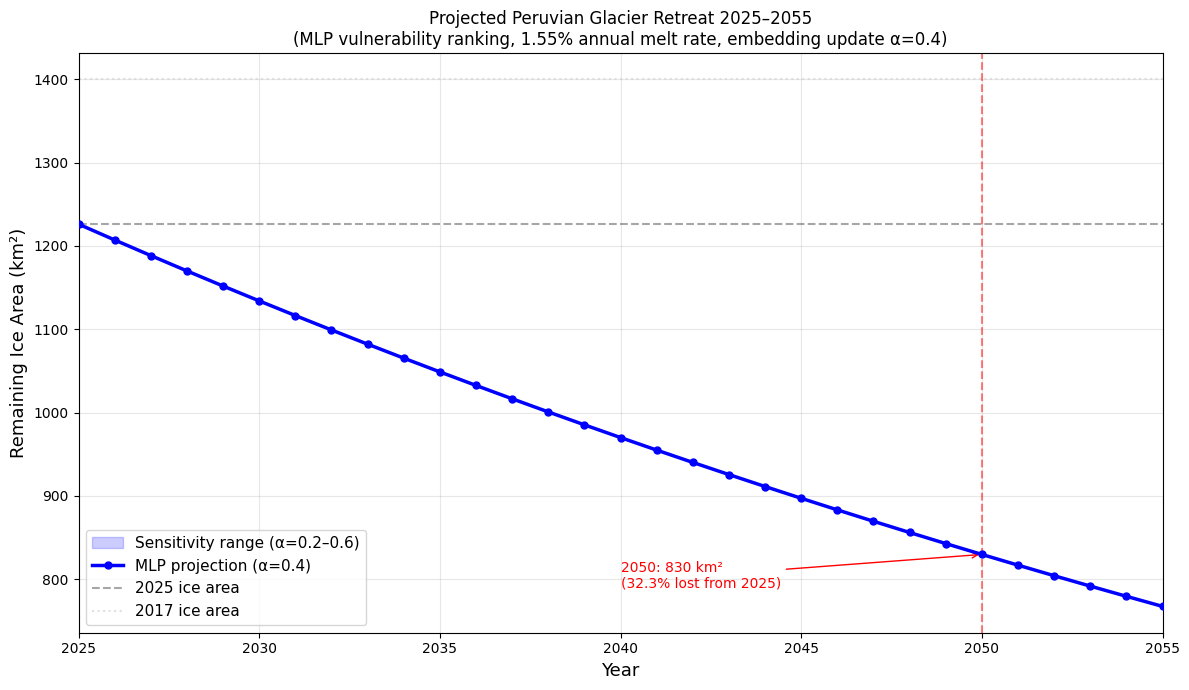

In [38]:
fig, ax = plt.subplots(figsize=(12, 7))

years = [y for y, _ in primary_history]
areas_primary = [a for _, a in primary_history]

# Sensitivity band
all_areas = np.array([[a for _, a in sensitivity_histories[alpha]]
                       for alpha in sorted(SENSITIVITY_ALPHAS)])
area_min = all_areas.min(axis=0)
area_max = all_areas.max(axis=0)

ax.fill_between(years, area_min, area_max,
                alpha=0.2, color='blue',
                label=f'Sensitivity range (α={min(SENSITIVITY_ALPHAS)}–{max(SENSITIVITY_ALPHAS)})')
ax.plot(years, areas_primary, 'b-o', linewidth=2.5, markersize=5,
        label=f'MLP projection (α={PRIMARY_ALPHA})', zorder=5)

# Reference lines
ax.axhline(y=start_area, color='gray', linestyle='--',
           alpha=0.7, label='2025 ice area')
ax.axhline(y=13_996_828 * PIXEL_AREA, color='lightgray',
           linestyle=':', alpha=0.7, label='2017 ice area')

# 2050 annotation
area_2050 = dict(primary_history).get(2050, None)
if area_2050:
    loss_2050 = (start_area - area_2050) / start_area * 100
    ax.axvline(x=2050, color='red', linestyle='--', alpha=0.5)
    ax.annotate(f'2050: {area_2050:.0f} km²\n({loss_2050:.1f}% lost from 2025)',
                xy=(2050, area_2050),
                xytext=(2040, area_2050 - 40),
                fontsize=10, color='red',
                arrowprops=dict(arrowstyle='->', color='red'))

ax.set_xlabel('Year', fontsize=13)
ax.set_ylabel('Remaining Ice Area (km²)', fontsize=13)
ax.set_title('Projected Peruvian Glacier Retreat 2025–2055\n'
             '(MLP vulnerability ranking, 1.55% annual melt rate, '
             f'embedding update α={PRIMARY_ALPHA})',
             fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xlim(2025, 2055)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'glacier_retreat_projection.png', dpi=150, bbox_inches='tight')
plt.show()

In [39]:
# Save area history
df_history = pd.DataFrame(primary_history, columns=['year', 'ice_area_km2'])
df_history['ice_loss_km2'] = start_area - df_history['ice_area_km2']
df_history['ice_loss_pct'] = df_history['ice_loss_km2'] / start_area * 100
df_history.to_parquet(RESULTS_DIR / 'simulation_area_history.parquet', index=False)

# Save per-pixel melt years
primary_df.to_parquet(RESULTS_DIR / 'simulation_melt_years.parquet', index=False)

print("Saved results")
print(f"\nKey figures:")
print(f"  2025: {start_area:.2f} km²")
for target in [2035, 2045, 2050, 2055]:
    area = dict(primary_history).get(target)
    if area:
        loss = (start_area - area) / start_area * 100
        print(f"  {target}: {area:.2f} km² ({loss:.1f}% lost from 2025)")

Saved results

Key figures:
  2025: 1226.07 km²
  2035: 1048.75 km² (14.5% lost from 2025)
  2045: 897.08 km² (26.8% lost from 2025)
  2050: 829.68 km² (32.3% lost from 2025)
  2055: 767.34 km² (37.4% lost from 2025)


In [40]:
# Correct annualised rate from compounding
total_loss_fraction = 0.29  # 29% lost over 16 years
n_years = 16

# If remaining(t) = start × (1 - r)^t
# Then (1 - r)^16 = 0.71 (71% remaining)
# So r = 1 - 0.71^(1/16)
r_compound = 1 - (1 - total_loss_fraction) ** (1 / n_years)
print(f"Compounded annual rate: {r_compound*100:.2f}%")

# Compare to your observed rate
r_yours = 1 - (1 - 0.124) ** (1 / 8)
print(f"Your compounded annual rate: {r_yours*100:.2f}%")

Compounded annual rate: 2.12%
Your compounded annual rate: 1.64%
